# Credit Card Fraud Detection


##Team No. 2

### Angel | Nicole | Anand | Afthab

##Data Exploration and Preprocessing


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files

uploaded = files.upload()


Saving creditcard.csv to creditcard.csv


In [4]:
df = pd.read_csv("creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
df.shape

(284807, 31)

In [10]:
print(f"Dataset contains {df.shape[0]:,} rows and {df.shape[1]} columns.")

Dataset contains 284,807 rows and 31 columns.


In [11]:
print("Data types:")
print(df.dtypes.value_counts())

Data types:
float64    30
int64       1
Name: count, dtype: int64


In [12]:
missing_values = df.isnull().sum().sum()

print("Total missing values:", missing_values)

Total missing values: 0


In [9]:
df['Class'].value_counts()

,count
Class,
0,284315
1,492


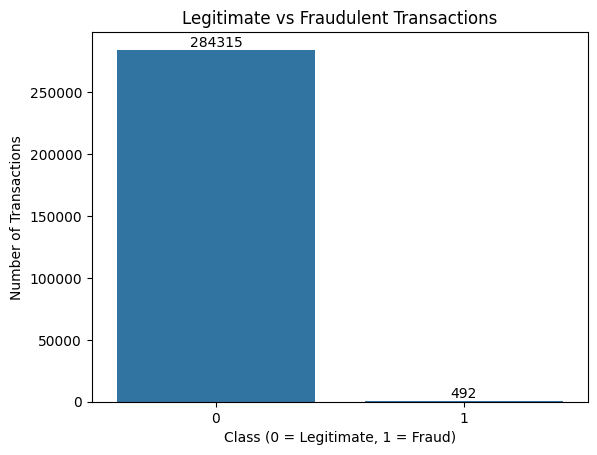

In [17]:
ax = sns.countplot(x='Class', data=df)

plt.title('Legitimate vs Fraudulent Transactions')
plt.xlabel('Class (0 = Legitimate, 1 = Fraud)')
plt.ylabel('Number of Transactions')

for container in ax.containers:
    ax.bar_label(container)

plt.show()

In [18]:
print("Minimum amount:", df['Amount'].min())
print("Maximum amount:", df['Amount'].max())
print("Average amount:", df['Amount'].mean())

Minimum amount: 0.0
Maximum amount: 25691.16
Average amount: 88.34961925093133


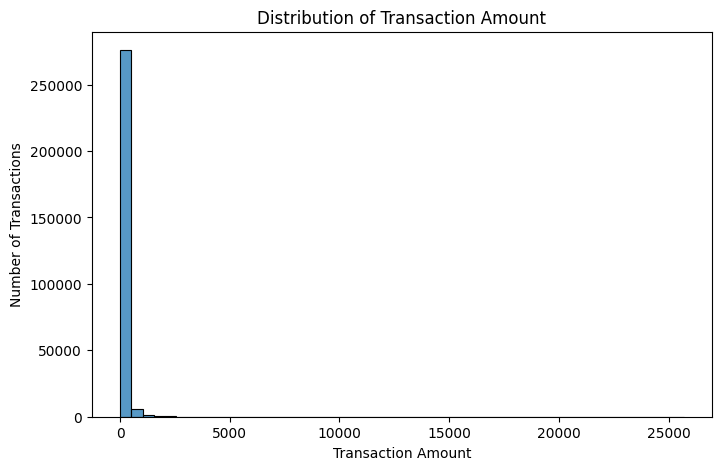

In [19]:
plt.figure(figsize=(8, 5))

sns.histplot(df['Amount'], bins=50)

plt.title('Distribution of Transaction Amount')
plt.xlabel('Transaction Amount')
plt.ylabel('Number of Transactions')
plt.show()

In [20]:
print("Minimum time:", df["Time"].min())
print("Maximum time:", df["Time"].max())
print("Average time:", df["Time"].mean())

Minimum time: 0.0
Maximum time: 172792.0
Average time: 94813.85957508067


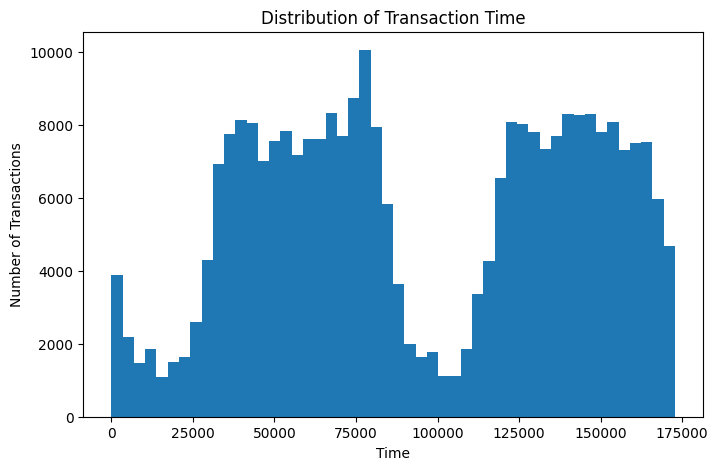

In [21]:
plt.figure(figsize=(8, 5))

plt.hist(df["Time"], bins=50)

plt.title("Distribution of Transaction Time")
plt.xlabel("Time")
plt.ylabel("Number of Transactions")

plt.show()

In [22]:
X = df.drop("Class", axis=1)
y = df["Class"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (284807, 30)
Target shape: (284807,)


In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (227845, 30)
Testing data: (56962, 30)


In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train["Amount"] = scaler.fit_transform(X_train[["Amount"]])
X_test["Amount"] = scaler.transform(X_test[["Amount"]])